## Veridi Logistics Audit
Using the Olist Brazilian E-Commerce dataset to audit delivery performance and its impact on customer sentiment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


### Story 1: Building the Master Dataset


In [2]:
orders = pd.read_csv(f'{path}/olist_orders_dataset.csv')
reviews = pd.read_csv(f'{path}/olist_order_reviews_dataset.csv')
customers = pd.read_csv(f'{path}/olist_customers_dataset.csv')
products = pd.read_csv(f'{path}/olist_products_dataset.csv')
translations = pd.read_csv(f'{path}/product_category_name_translation.csv')

print("orders:", orders.shape)
print("reviews:", reviews.shape)
print("customers:", customers.shape)
print("products:", products.shape)
print("translations:", translations.shape)

orders: (99441, 8)
reviews: (99224, 7)
customers: (99441, 5)
products: (32951, 9)
translations: (71, 2)


In [3]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [4]:
reviews.head(3)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


In [5]:
customers.head(3)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [6]:
products.head(3)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


In [7]:
translations.head(3)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


In [8]:
reviews_clean = reviews.sort_values('review_answer_timestamp', ascending=False)
reviews_clean = reviews_clean.drop_duplicates(subset='order_id', keep='first')
print(reviews_clean['order_id'].duplicated().sum())
print(reviews_clean.shape)

0
(98673, 7)


In [9]:
master = orders.merge(reviews_clean, on='order_id', how='left')
master = master.merge(customers, on='customer_id', how='left')
print(master.shape)
master.head(3)

(99441, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


### Story 2: Delay Calculator

In [10]:
master['order_estimated_delivery_date'] = pd.to_datetime(master['order_estimated_delivery_date'])
master['order_delivered_customer_date'] = pd.to_datetime(master['order_delivered_customer_date'])
master['days_difference'] = (master['order_delivered_customer_date'] - master['order_estimated_delivery_date']).dt.days

def classify_delivery(days):
    if pd.isna(days):
        return 'Undelivered'
    elif days <= 0:
        return 'On Time'
    elif days <= 5:
        return 'Late'
    else:
        return 'Super Late'

master['delivery_status'] = master.apply(
    lambda row: 'Canceled/Unavailable' if row['order_status'] in ['canceled', 'unavailable']
    else classify_delivery(row['days_difference']),
    axis=1
)
print(master['delivery_status'].value_counts())

delivery_status
On Time                 89936
Super Late               3764
Late                     2770
Undelivered              1737
Canceled/Unavailable     1234
Name: count, dtype: int64


### Story 3: Geographic Analysis


In [11]:
delivered = master[~master['delivery_status'].isin(['Canceled/Unavailable', 'Undelivered'])]
state_stats = delivered.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status', lambda x: (x.isin(['Late', 'Super Late'])).sum())
).reset_index()

state_stats['pct_late'] = (state_stats['late_orders'] / state_stats['total_orders'] * 100).round(2)

state_stats = state_stats.sort_values('pct_late', ascending=False)
print(state_stats.head(10))

   customer_state  total_orders  late_orders  pct_late
1              AL           397           85     21.41
9              MA           717          125     17.43
24             SE           335           51     15.22
16             PI           476           66     13.87
5              CE          1279          176     13.76
21             RR            41            5     12.20
4              BA          3256          396     12.16
18             RJ         12350         1495     12.11
13             PA           946          106     11.21
7              ES          1995          214     10.73


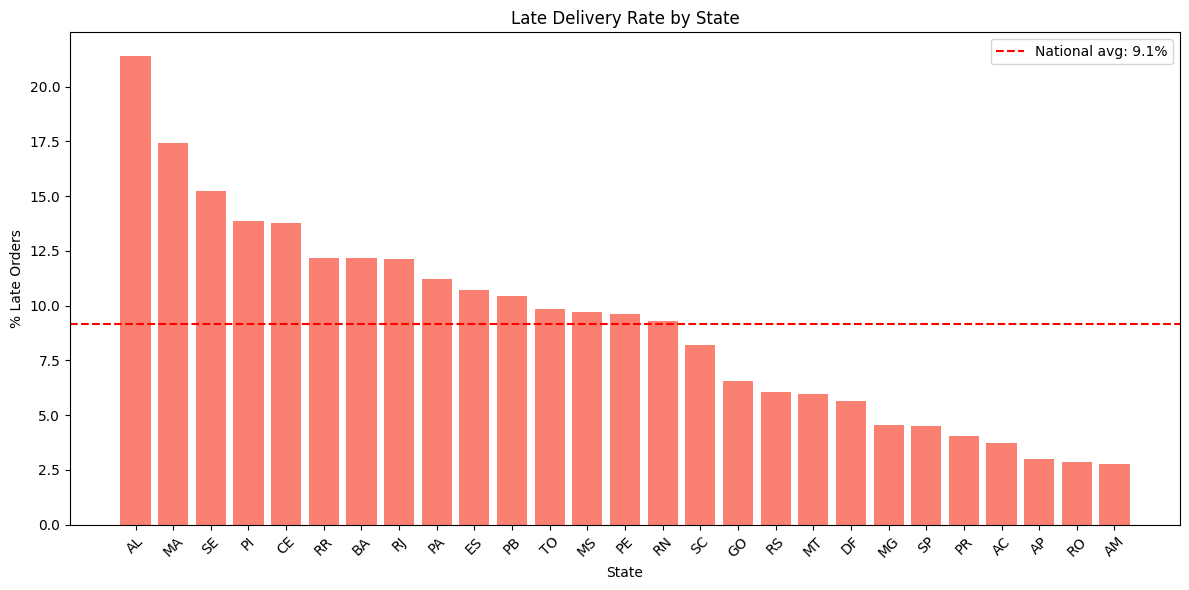

In [12]:
plt.figure(figsize=(12, 6))
plt.bar(state_stats['customer_state'], state_stats['pct_late'], color='salmon')
plt.axhline(y=state_stats['pct_late'].mean(), color='red', linestyle='--', label=f"National avg: {state_stats['pct_late'].mean():.1f}%")
plt.xlabel('State')
plt.ylabel('% Late Orders')
plt.title('Late Delivery Rate by State')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Story 4: Correlation Between Delays and Reviews

  delivery_status  review_score
0            Late      2.988244
1         On Time      4.290386
2      Super Late      1.736540


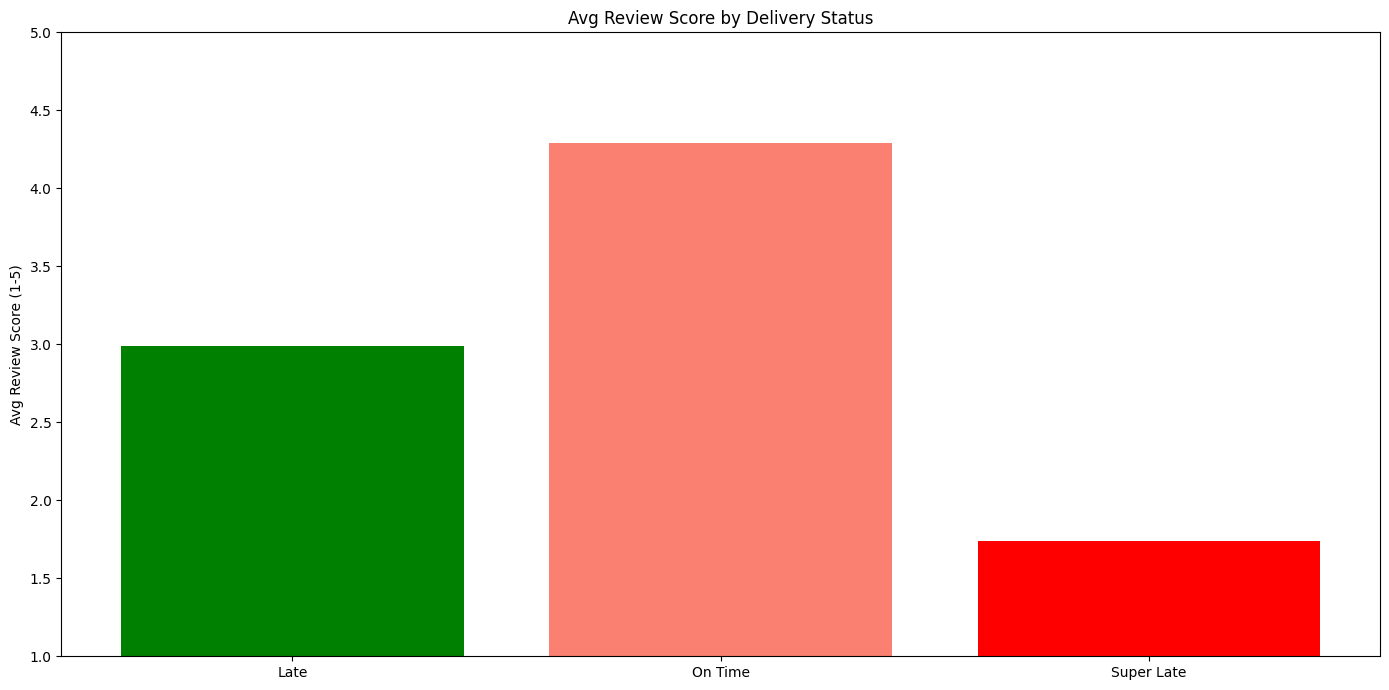

In [13]:
delivered = master[~master['delivery_status'].isin(['Canceled/Unavailable', 'Undelivered'])]

avg_score_by_status = delivered.groupby('delivery_status')['review_score'].mean().reset_index()
print(avg_score_by_status)

fig, ax1 = plt.subplots(1, 1, figsize=(14, 7))

ax1.bar(avg_score_by_status['delivery_status'], avg_score_by_status['review_score'], color=['green', 'salmon', 'red'])
ax1.set_title('Avg Review Score by Delivery Status')
ax1.set_ylabel('Avg Review Score (1-5)')
ax1.set_ylim(1, 5)

plt.tight_layout()
plt.show()

### Story 5: Product Category Translation

In [14]:
order_items = pd.read_csv(f'{path}/olist_order_items_dataset.csv')
print(order_items.shape)
order_items.head(3)

(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [15]:
products_translated = products.merge(
    translations,
    on='product_category_name',
    how='left'
)
order_items_with_product_info = order_items.sort_values('order_item_id').drop_duplicates(subset='order_id', keep='first')
order_items_with_product_info = order_items_with_product_info.merge(
    products_translated[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)
master = master.merge(
    order_items_with_product_info[['order_id', 'product_id', 'product_category_name_english']],
    on='order_id',
    how='left'
)
print(master.shape)
print(master['product_category_name_english'].isna().sum(), "orders without a category")
master.head(5)

(99441, 22)
2212 orders without a category


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,...,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,days_difference,delivery_status,product_id,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,...,2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-8.0,On Time,87285b34884572647811a353c7ac498a,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,...,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-6.0,On Time,595fac2a385ac33a80bd5114aec74eb8,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,...,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-18.0,On Time,aa4383b373c6aca5d8797843e5594415,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5.0,...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,-13.0,On Time,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5.0,...,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-10.0,On Time,65266b2da20d04dbe00c5c2d3bb7859e,stationery


### Story 6: Delay by Product Category

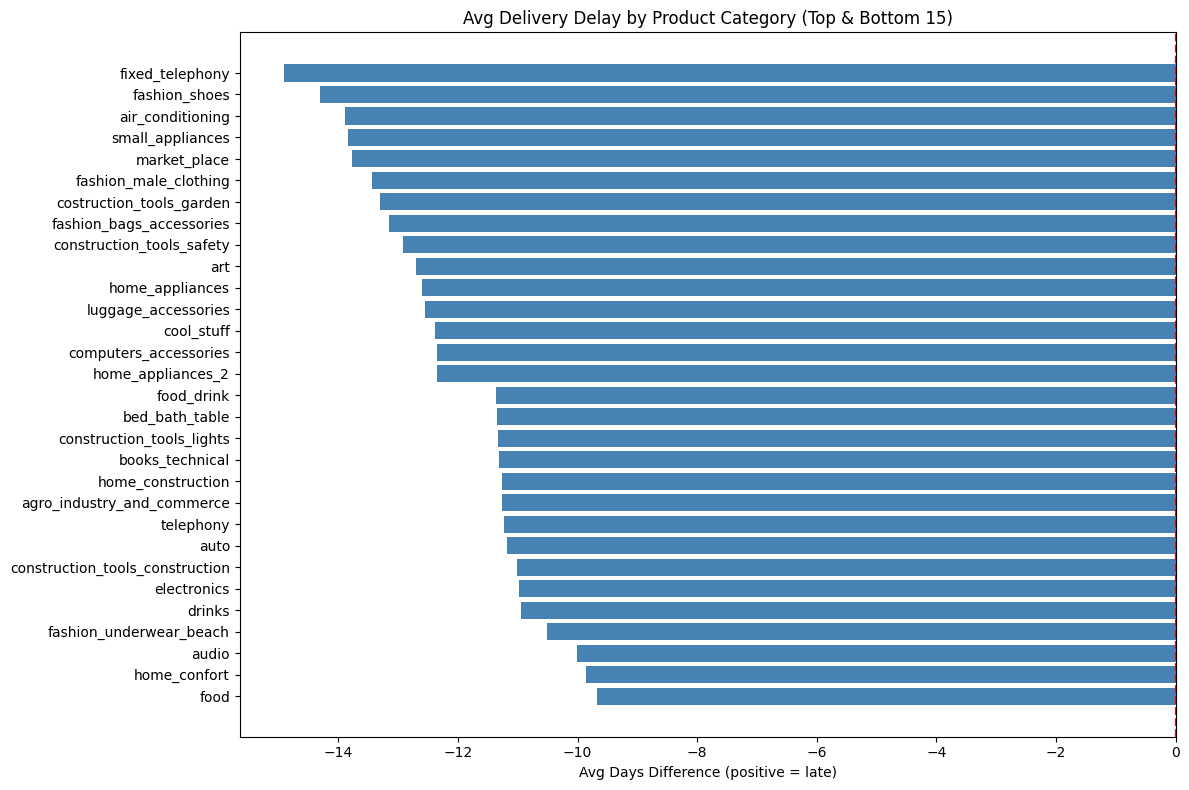

In [16]:
category_delays = master[master['delivery_status'] != 'Canceled/Unavailable'].groupby('product_category_name_english').agg(
    avg_delay=('days_difference', 'mean'),
    total_orders=('order_id', 'count')
).reset_index()
category_delays = category_delays[category_delays['total_orders'] >= 100]
category_delays = category_delays.sort_values('avg_delay', ascending=False)
top15 = pd.concat([category_delays.head(15), category_delays.tail(15)])

plt.figure(figsize=(12, 8))
plt.barh(top15['product_category_name_english'], top15['avg_delay'], color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', label='Estimated date')
plt.title("Avg Delivery Delay by Product Category (Top & Bottom 15)")
plt.xlabel("Avg Days Difference (positive = late)")
plt.tight_layout()
plt.show()

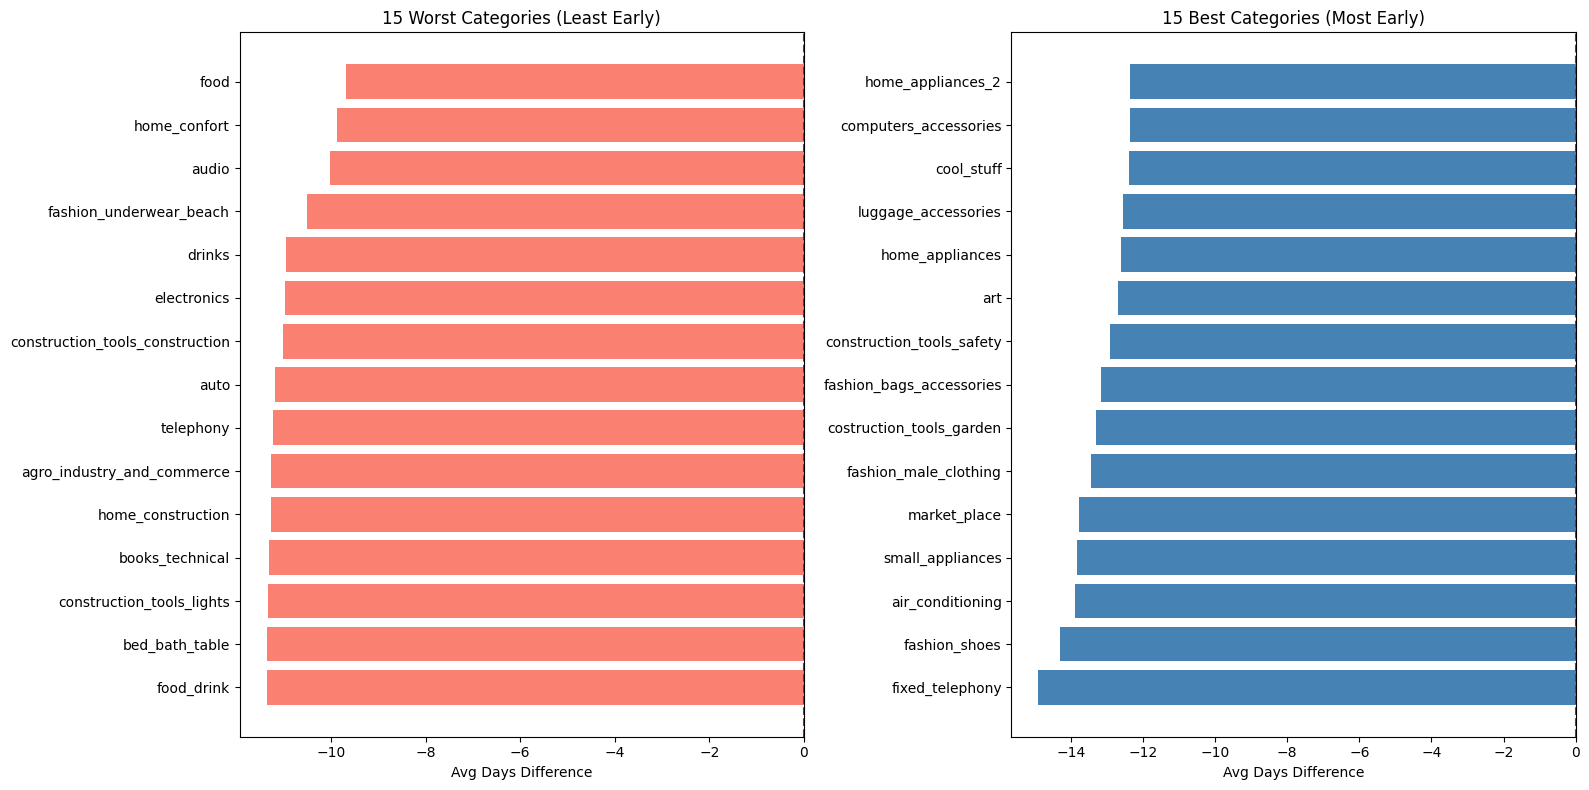

In [17]:
category_delays = category_delays.sort_values('avg_delay', ascending=True)

# top 15 least early and top 15 most early
worst15 = category_delays.tail(15)
best15 = category_delays.head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.barh(worst15['product_category_name_english'], worst15['avg_delay'], color='salmon')
ax1.set_title('15 Worst Categories (Least Early)')
ax1.set_xlabel('Avg Days Difference')
ax1.axvline(x=0, color='red', linestyle='--')

ax2.barh(best15['product_category_name_english'], best15['avg_delay'], color='steelblue')
ax2.set_title('15 Best Categories (Most Early)')
ax2.set_xlabel('Avg Days Difference')
ax2.axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()